In [ ]:
%pip install -r ../../requirements.txt

In [2]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
import hdbscan
import matplotlib.pyplot as plt
import umap
import networkx as nx
from matplotlib import cm
import pandas as pd
import numpy as np


## 1. Parsing dei sottografi da file TXT

La funzione `parse_subgraph(filepath)` legge un file di testo contenente più sottografi e li converte in una lista di grafi diretti di NetworkX.

Il formato atteso del file è:

- `S` → indica l’inizio di un nuovo sottografo  
- `v ID LABEL` → definisce un nodo con identificatore e attività associata  
- `d SOURCE TARGET LABEL` oppure `e SOURCE TARGET LABEL` → definisce un arco diretto

## 2. Sanitizzazione dei grafi

La funzione `sanitize_graph(g)` garantisce la consistenza strutturale del grafo prima dell’analisi.

Operazioni effettuate:

- Conversione del grafo in grafo non diretto.
- Rimozione dei nodi privi di attributo `label`.

## 3. Graph Embedding strutturale

La funzione `graph_embedding_features(graphs)` trasforma ogni grafo in un vettore numerico di 6 feature strutturali:

Le feature estratte sono:

- Numero di nodi  
- Numero di archi  
- Densità del grafo  
- Degree medio dei nodi  
- Numero di componenti connesse  
- Lunghezza media dei cammini (se il grafo è connesso)

Se il grafo è vuoto o non valido, viene ignorato.

## 4. Pipeline principale

La pipeline esegue le seguenti operazioni:

1. Lettura dei sottografi anomali e corretti dai file TXT.
2. Costruzione delle liste di grafi NetworkX.
3. Unione dei grafi in un unico dataset.
4. Estrazione dell’embedding strutturale.

Output finale:

- `X_embedding`: matrice numerica utilizzabile per clustering o analisi statistica.
- Shape della matrice stampata a video.


In [3]:
# ==========================================================
# PARSER TXT → LISTA DI GRAFI
# ==========================================================

def parse_subgraph(filepath):

    graphs = []
    G = None

    with open(filepath, 'r') as f:

        for line in f:

            line = line.strip()
            if not line:
                continue

            # Inizio nuovo sottografo
            if line == 'S':

                if G is not None and len(G.nodes) > 0:
                    graphs.append(G)

                G = nx.DiGraph()
                continue

            # Nodo
            if line.startswith('v '):

                if G is None:
                    continue

                parts = line.split(maxsplit=2)

                if len(parts) >= 3:
                    node_id = parts[1]
                    label = parts[2]

                    G.add_node(node_id, label=str(label))

            # Arco
            elif line.startswith('d ') or line.startswith('e '):

                if G is None:
                    continue

                parts = line.split(maxsplit=3)

                if len(parts) >= 4:
                    source = parts[1]
                    target = parts[2]
                    label = parts[3]

                    if source not in G.nodes:
                        G.add_node(source, label="UNK")

                    if target not in G.nodes:
                        G.add_node(target, label="UNK")

                    G.add_edge(source, target, label=str(label))

    if G is not None and len(G.nodes) > 0:
        graphs.append(G)

    return graphs


# ==========================================================
# SANITIZATION GRAFI
# ==========================================================

def sanitize_graph(g):

    g = nx.Graph(g)

    nodes_to_remove = []

    for n in g.nodes():
        if 'label' not in g.nodes[n]:
            nodes_to_remove.append(n)

    g.remove_nodes_from(nodes_to_remove)

    return g


# ==========================================================
# COSTRUZIONE VOCABOLARI SEMANTICI
# ==========================================================

def build_label_vocabulary(graphs):

    labels = set()

    for g in graphs:
        for _, data in g.nodes(data=True):
            labels.add(data.get("label", "UNK"))

    labels = sorted(list(labels))

    return {l: i for i, l in enumerate(labels)}


def build_edge_vocabulary(graphs):

    edges = set()

    for g in graphs:

        for u, v in g.edges():

            l1 = g.nodes[u].get("label", "UNK")
            l2 = g.nodes[v].get("label", "UNK")

            edges.add((l1, l2))

    edges = sorted(list(edges))

    return {e: i for i, e in enumerate(edges)}


# ==========================================================
# FEATURE SEMANTICHE
# ==========================================================

def node_semantic_features(g, vocab):

    vec = np.zeros(len(vocab))

    for _, data in g.nodes(data=True):

        label = data.get("label", "UNK")

        if label in vocab:
            vec[vocab[label]] = 1

    return vec


def edge_semantic_features(g, edge_vocab):

    vec = np.zeros(len(edge_vocab))

    for u, v in g.edges():

        l1 = g.nodes[u].get("label", "UNK")
        l2 = g.nodes[v].get("label", "UNK")

        pair = (l1, l2)

        if pair in edge_vocab:
            vec[edge_vocab[pair]] = 1

    return vec


# ==========================================================
# GRAPH EMBEDDING (STRUTTURA + SEMANTICA)
# ==========================================================

def graph_embedding_features(graphs, label_vocab, edge_vocab):

    embeddings = []

    # 1. Costruzione dinamica degli Header
    # Feature Strutturali
    structural_headers = [
        "NumeroNodi", 
        "NumeroArchi", 
        "Densita", 
        "GradoMedio", 
        "ComponentiConnesse", 
        "LunghezzaMediaCammino"
    ]
    
    # Feature Semantiche Nodi (invertiamo il dizionario per avere nome -> indice corretto)
    inv_label_vocab = {v: k for k, v in label_vocab.items()}
    node_headers = [f"Nodo_{inv_label_vocab[i]}" for i in range(len(label_vocab))]

    # Feature Semantiche Archi
    inv_edge_vocab = {v: k for k, v in edge_vocab.items()}
    edge_headers = [f"Arco_{inv_edge_vocab[i][0]}_{inv_edge_vocab[i][1]}" for i in range(len(edge_vocab))]

    # Header finale completo
    feature_names = structural_headers + node_headers + edge_headers

    # 2. Estrazione delle feature
    for g in graphs:

        if len(g.nodes()) == 0:
            continue

        g = sanitize_graph(g)

        # --- Feature Strutturali ---
        num_nodes = len(g.nodes())
        num_edges = len(g.edges())
        density = nx.density(g)
        degrees = [d for _, d in g.degree()]
        avg_degree = np.mean(degrees) if len(degrees) > 0 else 0

        try:
            scc = nx.number_connected_components(g)
        except:
            scc = 0

        try:
            if len(g.nodes()) > 1 and nx.is_connected(g):
                avg_path_length = nx.average_shortest_path_length(g)
            else:
                avg_path_length = 0
        except:
            avg_path_length = 0

        structural_features = np.array([
            num_nodes, num_edges, density, avg_degree, scc, avg_path_length
        ])

        # --- Feature Semantiche ---
        node_features = node_semantic_features(g, label_vocab)
        edge_features = edge_semantic_features(g, edge_vocab)

        # --- Concatenazione ---
        graph_vector = np.concatenate([
            structural_features,
            node_features,
            edge_features
        ])

        embeddings.append(graph_vector)

    # 3. Restituisci il DataFrame con i nomi delle colonne
    return pd.DataFrame(embeddings, columns=feature_names)


# ==========================================================
# MAIN PIPELINE
# ==========================================================

# Path dataset
anomalous_path = "../../datasets/custom/anomalous_sub.txt"
correct_path = "../../datasets/custom/correct_sub.txt"

# Parsing
anomalous_graphs = parse_subgraph(anomalous_path)
correct_graphs = parse_subgraph(correct_path)

print("Anomalous graphs:", len(anomalous_graphs))
print("Correct graphs:", len(correct_graphs))

all_graphs = anomalous_graphs + correct_graphs

# Costruzione vocabolari
label_vocab = build_label_vocabulary(all_graphs)
edge_vocab = build_edge_vocabulary(all_graphs)

print("Numero label:", len(label_vocab))
print("Numero relazioni tra label:", len(edge_vocab))

# Embedding (ora restituisce un DataFrame)
df_embedding = graph_embedding_features(all_graphs, label_vocab, edge_vocab)

print("\nEmbedding DataFrame shape:", df_embedding.shape)
print("\nAnteprima delle colonne generate:")
print(df_embedding.head())

Anomalous graphs: 27
Correct graphs: 140
Numero label: 11
Numero relazioni tra label: 64

Embedding DataFrame shape: (167, 81)

Anteprima delle colonne generate:
   NumeroNodi  NumeroArchi  Densita  GradoMedio  ComponentiConnesse  \
0         4.0          3.0     0.50        1.50                 1.0   
1         8.0          7.0     0.25        1.75                 1.0   
2         4.0          3.0     0.50        1.50                 1.0   
3         5.0          4.0     0.40        1.60                 1.0   
4         4.0          3.0     0.50        1.50                 1.0   

   LunghezzaMediaCammino  Nodo_AddPenalty  Nodo_AppealToJudge  \
0               1.666667              0.0                 0.0   
1               3.000000              1.0                 0.0   
2               1.666667              0.0                 0.0   
3               2.000000              1.0                 0.0   
4               1.666667              0.0                 0.0   

   Nodo_AppealToPref

# Riduzione dimensionale e clustering degli embedding grafici

Questo blocco di codice implementa una pipeline di analisi non supervisionata su rappresentazioni vettoriali di grafi. L’obiettivo è trasformare gli embedding ad alta dimensionalità in uno spazio latente compatto e strutturare i dati in cluster significativi, mantenendo la relazione topologica tra i pattern osservati.


 *Riduzione dimensionale*

La dimensionalità degli embedding viene ridotta utilizzando UMAP, un algoritmo non lineare che preserva la struttura locale dei dati nello spazio latente. La riduzione dimensionale facilita la visualizzazione, riduce il rumore e rende più efficiente il clustering.

 *Clustering non supervisionato*

I dati proiettati nello spazio ridotto vengono clusterizzati utilizzando HDBSCAN, un algoritmo density-based capace di identificare gruppi di punti ad alta densità e di trattare automaticamente gli outlier come rumore.



In [27]:
X_scaled = StandardScaler().fit_transform(df_embedding)

import umap
X_reduced = umap.UMAP(
    n_neighbors=12,
    n_components=8,
    min_dist=0.05,
    metric='cosine',
    random_state=42
).fit_transform(X_scaled)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=4,
    min_samples=2
)

labels = clusterer.fit_predict(X_reduced)


print("Numero grafi:", df_embedding.shape[0])
print("Dimensione embedding:", df_embedding.shape[1])
print("Noise points:", np.sum(labels == -1))

Numero grafi: 167
Dimensione embedding: 81
Noise points: 17


# Visualizzazione dei cluster tramite UMAP

Questa sezione della pipeline consente di visualizzare i risultati del clustering ottenuto con HDBSCAN riducendo la dimensionalità dello spazio embedding.

Poiché l’embedding dei grafi ha dimensione 6, viene applicata una tecnica di riduzione dimensionale non lineare per rappresentare i dati in 2D.

---

### 1. Riduzione dimensionale con UMAP

Viene utilizzato **Uniform Manifold Approximation and Projection (UMAP)** per proiettare i dati dallo spazio ad alta dimensione allo spazio bidimensionale.

---

### 2. Visualizzazione dei cluster

I punti proiettati nello spazio 2D sono colorati in base all’etichetta di clustering ottenuta da HDBSCAN.

- Cluster con label ≥ 0 → rappresentano pattern strutturali ricorrenti dei sottografi.
- Label = -1 → rappresentano outlier o comportamenti non densamente supportati (rumore).

Ogni cluster è rappresentato con un marker differente:

- `o` → punti appartenenti a cluster strutturali
- `x` → punti classificati come rumore

---


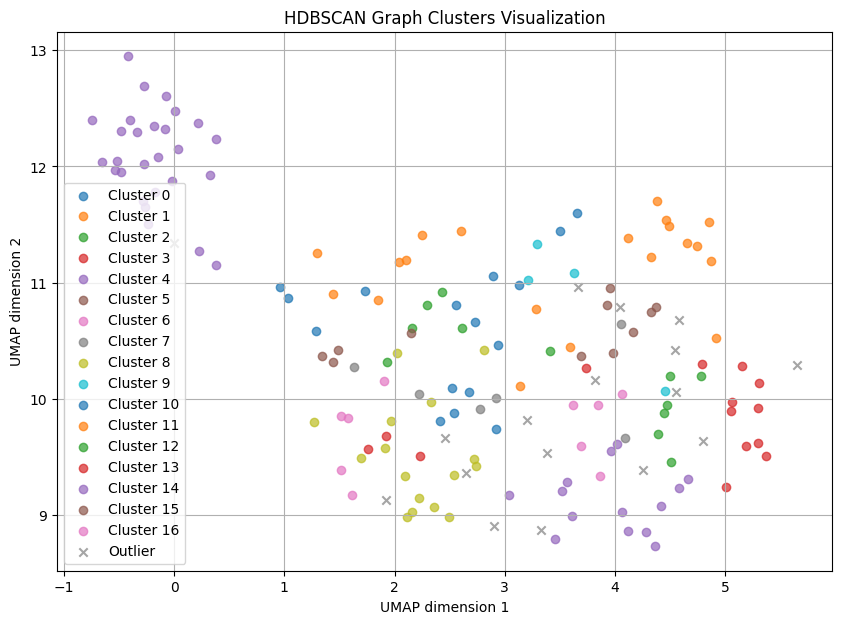

Silhouette score: 0.13338064330858182

Numero grafi rumorosi: 17
Indici grafi rumorosi: [  9  14  19  21  27  43  48  54  61  76  82  88 114 130 131 138 156]


In [28]:
# ===============================
# RIDUZIONE DIMENSIONALE
# ===============================

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean'
)

X_2d = reducer.fit_transform(X_scaled)

# ===============================
# PLOT CLUSTER
# ===============================

plt.figure(figsize=(10,7))

unique_labels = set(labels)

for cluster_id in unique_labels:

    mask = labels == cluster_id

    if cluster_id == -1:
        label_name = "Outlier"
        marker_style = 'x'
    else:
        label_name = f"Cluster {cluster_id}"
        marker_style = 'o'

    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        label=label_name,
        alpha=0.7,
        marker=marker_style
    )

plt.legend()
plt.title("HDBSCAN Graph Clusters Visualization")
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.grid(True)
plt.show()

# ===============================
# SILHOUETTE SCORE (senza outlier)
# ===============================

mask = labels != -1
score = silhouette_score(X_scaled[mask], labels[mask])

print("Silhouette score:", score)

# ===============================
# INDIVIDUAZIONE GRAFI RUMOROSI
# ===============================

noise_indices = np.where(labels == -1)[0]

print("\nNumero grafi rumorosi:", len(noise_indices))
print("Indici grafi rumorosi:", noise_indices)


### Profilazione dei Cluster

La seguente cella di codice analizza le caratteristiche distintive di ciascun cluster appena individuato, confrontandole con l'andamento generale dell'intero dataset. 

Nello specifico, il codice:
* **Integra le etichette:** Associa i risultati del clustering al dataset originale (non scalato) per mantenere l'interpretabilità reale dei valori.
* **Confronta le medie:** Calcola la media di ogni feature per il singolo cluster e la confronta con la media globale dell'intero dataset.
* **Estrae il profilo:** Per ogni gruppo (incluso il cluster `-1` che rappresenta il rumore/outlier), identifica e stampa:
  * Il numero totale di elementi (grafi) al suo interno.
  * Le **5 feature maggiormente sopra la media** globale (espresse in variazione percentuale).
  * Le **5 feature maggiormente sotto la media** globale (espresse in variazione percentuale).

In [23]:

# 1. Uniamo le etichette del clustering al DataFrame ORIGINALE (non scalato)
df_analysis = df_embedding.copy()
df_analysis['Cluster'] = labels

# 2. Calcoliamo la media di ogni feature per ogni cluster
cluster_means = df_analysis.groupby('Cluster').mean()

# 3. Calcoliamo la media globale di tutto il dataset
global_means = df_analysis.drop(columns=['Cluster']).mean()

# 4. Iteriamo su TUTTI i cluster trovati (ordinati in modo crescente)
unique_labels = sorted(list(set(labels)))

for target_cluster in unique_labels:
    
    # Gestione del nome testuale per chiarezza (distinguiamo il rumore di HDBSCAN)
    if target_cluster == -1:
        cluster_name = "OUTLIER / RUMORE (Cluster -1)"
    else:
        cluster_name = f"CLUSTER {target_cluster}"
        
    print(f"\n{'='*50}")
    print(f"=== ANALISI DEL {cluster_name} ===")
    print(f"{'='*50}")
    
    # Contiamo quanti grafi ci sono in questo cluster
    num_elements = (df_analysis['Cluster'] == target_cluster).sum()
    print(f"Numero di grafi in questo gruppo: {num_elements}\n")
    
    # Calcoliamo la differenza percentuale rispetto alla media globale
    # (Aggiungiamo un piccolo epsilon per evitare divisioni per zero)
    diff_percentuale = ((cluster_means.loc[target_cluster] - global_means) / (global_means + 1e-9)) * 100
    
    # Ordiniamo le feature in ordine decrescente
    top_features = round(diff_percentuale.sort_values(ascending=False), 2)
    
    print("📈 Le 5 feature più 'SOPRA la media' rispetto al globale (%):")
    print(top_features.head(5).to_string())
    
    print("\n📉 Le 5 feature più 'SOTTO la media' rispetto al globale (%):")
    print(top_features.tail(5).to_string())
    print("\n")


=== ANALISI DEL OUTLIER / RUMORE (Cluster -1) ===
Numero di grafi in questo gruppo: 17

📈 Le 5 feature più 'SOPRA la media' rispetto al globale (%):
Arco_Payment_AppealToJudge                   882.35
Arco_SendAppeal_NotifyOffenders              882.35
Arco_Notification_SendForCreditCollection    882.35
Arco_AppealToJudge_Payment                   461.34
Arco_CreateFine_Payment                      391.18

📉 Le 5 feature più 'SOTTO la media' rispetto al globale (%):
Arco_AppealToPrefecture_SendFine     -100.0
Arco_SendAppeal_Notification         -100.0
Arco_ReceiveResults_Payment          -100.0
Arco_CreateFine_AppealToPrefecture   -100.0
Arco_ReceiveResults_AppealToJudge    -100.0



=== ANALISI DEL CLUSTER 0 ===
Numero di grafi in questo gruppo: 4

📈 Le 5 feature più 'SOPRA la media' rispetto al globale (%):
Arco_SendAppeal_SendFine              4075.00
Arco_CreateFine_AppealToPrefecture    1418.18
Arco_SendFine_Payment                 1291.67
Arco_AppealToPrefecture_SendAppeal     

# Considerazioni sul clustering

1. Il Rumore Estremo (Cluster -1: Le Anomalie Caotiche)

    Hanno una serie di transizioni completamente illogiche o molto rare, come Arco_Payment_AppealToJudge (si fa ricorso al giudice dopo aver pagato?) o Arco_CreateFine_Payment (pagamento immediato senza nemmeno la notifica?).

    Interpretazione: Questi grafi rappresentano probabilmente errori di inserimento dati, bug nel sistema IT, o casi limite rarissimi in cui la sequenza standard degli eventi è saltata completamente.

2. I Loop e i "Rimbalzi" Burocratici
    Alcuni cluster mostrano chiaramente grafi bloccati in cicli ripetitivi o passaggi insoliti tra entità.

    Cluster 0 (4 grafi) - Il Loop del Ricorso: Qui si vede un rimbalzo diretto e anomalo (Arco_SendAppeal_SendFine a +4075% e Arco_AppealToPrefecture_SendAppeal). Sembra un errore di instradamento in cui la multa e il ricorso continuano a incrociarsi.

    Cluster 12 (6 grafi) e Cluster 10 (12 grafi) - Confusione sui Pagamenti: Nel Cluster 12 emerge un forte Arco_Payment_ReceiveResults (+1291%); nel Cluster 10 c'è Arco_Payment_AddPenalty (+1291%). Entrambi mostrano comportamenti anomali dopo un pagamento (l'aggiunta di una penale post-pagamento è un red flag forte per un'anomalia).

3. I Percorsi del Giudice (Appeal To Judge)
    Il ricorso al giudice di pace è chiaramente un sub-processo distinto e l'algoritmo lo ha frammentato in casistiche specifiche:

    Cluster 3 (4 grafi): Un percorso molto specifico e raro dove Prefettura e Giudice si passano la palla (Arco_AppealToPrefecture_AppealToJudge e Arco_AppealToJudge_SendAppeal entrambi a +4075%).

    Cluster 7 (6 grafi): Un altro iter giudiziario anomalo, dove la notifica porta direttamente al giudice (Arco_Notification_AppealToJudge +2683%).

    Cluster 11 (13 grafi): Questo è il gruppo dove si ricevono i risultati e si va al giudice (Arco_ReceiveResults_AppealToJudge +970%), con successiva notifica ai trasgressori (Arco_AppealToJudge_NotifyOffenders +899%).

4. Il Percorso del Recupero Crediti (Credit Collection)
    L'esito negativo (o il mancato pagamento prolungato) crea cluster molto netti.

    Cluster 6 (5 grafi): Penale che va direttamente a recupero crediti (Arco_AddPenalty_SendForCreditCollection +2126%).

    Cluster 14 (14 grafi): Il Giudice manda a recupero crediti (Arco_AppealToJudge_SendForCreditCollection +854%).

    Cluster 15 (7 grafi): Questo è molto anomalo: c'è un pagamento che innesca comunque il recupero crediti (Arco_Payment_SendForCreditCollection +1490%). Questa è una potenziale falla di sistema (es. pagamento registrato in ritardo mentre la pratica di recupero è già partita).

    Cluster 16 (5 grafi): Il trasgressore viene notificato e innesca un ricorso che va dritto a recupero crediti (Arco_SendAppeal_SendForCreditCollection +3240%).

5. Il Cluster "Normale" (Cluster 4)
    Cluster 4 (27 grafi): È il cluster più grande. Le percentuali di scostamento dalla media qui sono molto più basse (il picco è "solo" +518%, rispetto ai +4000% degli altri). Sebbene mostri alcune deviazioni (come il SendFine_Payment), la bassa intensità delle feature semantiche suggerisce che questo gruppo rappresenta il bacino dei processi più "standard" o con deviazioni molto minori, dove le feature strutturali (come si evince dalla Densita a +98%) giocano ancora un ruolo per compattare il gruppo

### Valutazione dei Cluster (Ground Truth vs Clustering)

Il prossimo codice valuta l'effettiva qualità del clustering confrontando i gruppi appena creati con le etichette reali (la "Ground Truth"). 

Nel dettaglio, il codice esegue questi passaggi:
* **Costruisce la Ground Truth:** Crea una lista di etichette reali assegnando `1` ai grafi noti come anomali e `0` a quelli corretti.
* **Verifica la coerenza:** Effettua un controllo di sicurezza stampando le lunghezze per assicurarsi che le etichette si allineino perfettamente alle righe del dataset.
* **Calcola le statistiche di gruppo:** Raggruppa i dati per cluster e conta il numero totale di grafi e quante *vere anomalie* sono finite in ciascun gruppo.
* **Determina la "Purezza":** Calcola la percentuale di anomalie per ogni cluster.

In [18]:

ground_truth = [1] * len(anomalous_graphs) + [0] * len(correct_graphs)

# 2. Verifica di sicurezza: stampiamo le lunghezze per essere certi
print(f"Lunghezza DataFrame: {len(df_analysis)}")
print(f"Lunghezza Ground Truth: {len(ground_truth)}")

# 3. Ora l'assegnazione funzionerà perfettamente
df_analysis['Is_Anomaly_GT'] = ground_truth

# 4. Calcoliamo le statistiche per ogni cluster come prima
cluster_evaluation = df_analysis.groupby('Cluster').agg(
    Totale_Grafi=('Cluster', 'count'),
    Anomalie_GT=('Is_Anomaly_GT', 'sum')
)

# Calcoliamo la percentuale (purezza del cluster)
cluster_evaluation['Percentuale_Anomalie'] = (cluster_evaluation['Anomalie_GT'] / cluster_evaluation['Totale_Grafi']) * 100

print("\n--- VALUTAZIONE CLUSTER ---")
print(cluster_evaluation.sort_values(by='Percentuale_Anomalie', ascending=False))

Lunghezza DataFrame: 167
Lunghezza Ground Truth: 167

--- VALUTAZIONE CLUSTER ---
         Totale_Grafi  Anomalie_GT  Percentuale_Anomalie
Cluster                                                 
 0                  4            2             50.000000
 4                 27            7             25.925926
 3                  4            1             25.000000
 5                  4            1             25.000000
 9                  4            1             25.000000
-1                 17            4             23.529412
 6                  5            1             20.000000
 12                 6            1             16.666667
 7                  6            1             16.666667
 11                13            2             15.384615
 15                 7            1             14.285714
 8                 16            2             12.500000
 13                10            1             10.000000
 10                12            1              8.333333
 14   

# Considerazioni
1. Il Paradosso del Cluster 4 (Anomalie Invisibili)
    Il Cluster 4 è il gruppo più grande (27 grafi) e, come avevamo visto prima, è quello che rappresenta il processo "standard" o più normale. Eppure contiene il numero assoluto più alto di anomalie (7 grafi, il 25%).

    Cosa significa: Queste 7 anomalie sono strutturalmente perfette. Hanno gli stessi nodi e gli stessi archi delle pratiche andate a buon fine.

    Conclusione: Perché il business le ha flaggate come anomalie? Quasi certamente si tratta di Anomalie di Performance (Tempo/Costo) o di violazioni di regole di business interne (es. l'importo della multa era sbagliato, oppure la pratica è rimasta ferma 6 mesi in uno stato). La struttura del grafo non basta per rilevarle.

2. Le Potenziali "Best Practice" o "Falle di Sistema" (I Cluster a 0%)
    Guarda in fondo alla tabella. I Cluster 2, 1 e 16 hanno lo 0% di anomalie. Il business li considera grafi perfettamente sani.

    Cosa significa: L'algoritmo di machine learning li ha isolati perché sono strutturalmente molto diversi dalla media, ma chi supervisiona il processo non li ha mai segnalati come errori.

    Il caso del Cluster 16: Ricordi l'analisi precedente? Il Cluster 16 (5 grafi) aveva l'anomalia Arco_SendAppeal_SendForCreditCollection a +3240%. Un ricorso che va dritto a recupero crediti.

    Ipotesi A (Falla sfuggita): È un gravissimo errore procedurale che il sistema di controllo del business non riesce a intercettare (non sanno di avere questo problema).

    Ipotesi B (Best Practice / Fast Track): È una procedura speciale e perfettamente legale (magari per recidivi) che accelera la chiusura della pratica. Se così fosse, hai appena trovato una variante del processo da formalizzare.

3. I Loop Incoerenti (Cluster 0)
    Il Cluster 0 ha 4 grafi, di cui 2 anomali (50%).

    Cosa significa: In questo cluster (che avevamo definito "Il Loop del Ricorso" per i continui rimbalzi tra ricorso e multa), la metà dei casi è considerata un'anomalia, l'altra metà no.

    Conclusione: C'è un'incoerenza nelle regole di business. Probabilmente gli operatori agiscono "a sentimento": a volte lasciano passare questi loop infiniti, altre volte li bloccano e li flaggano come anomalie. Questo è un punto debole del processo aziendale che va standardizzato.

4. Il Rumore (Cluster -1)
    Su 17 grafi caotici, solo 4 sono flaggati come anomalie (23%).

    Cosa significa: Ben 13 grafi che l'algoritmo considera "illeggibili" o "spaghetti process" (processi estremamente aggrovigliati) per il business sono normali. Anche qui, probabilmente il business non monitora la complessità del processo, ma guarda solo se alla fine la multa è stata pagata o meno.

# Estrazione dei prototipi rappresentativi dei cluster (Medoidi)

Questa funzione consente di identificare il **grafo prototipo** di ogni cluster ottenuto tramite HDBSCAN.

Il prototipo è definito come il **medoid del cluster**, cioè il grafo che minimizza la distanza media rispetto agli altri grafi appartenenti allo stesso cluster nello spazio embedding.

---

### 1. Definizione del prototipo di cluster

Per ogni cluster (escludendo il cluster di rumore etichettato con -1):

1. Vengono individuati gli indici dei grafi appartenenti al cluster.
2. Si estraggono i corrispondenti vettori embedding.
3. Si calcola la matrice di distanza pairwise all’interno del cluster.


### 2. Selezione del medoid

Si sceglie il medoide che rappresenta il grafo più centrale e stabile del cluster.

### 3. Costruzione del dizionario dei prototipi

Il risultato finale è un dizionario:


In [28]:
from sklearn.metrics import pairwise_distances

def extract_cluster_prototypes(graphs, embeddings, labels):

    prototypes = {}

    unique_clusters = set(labels)

    # Converti embeddings in numpy array (solo embedding!)
    embeddings = np.array(embeddings)

    for cluster_id in unique_clusters:

        if cluster_id == -1:
            continue

        cluster_indices = np.where(labels == cluster_id)[0]

        if len(cluster_indices) == 0:
            continue

        cluster_embeddings = embeddings[cluster_indices]

        # distanza pairwise dentro cluster
        dist_matrix = pairwise_distances(cluster_embeddings)

        medoid_local_idx = np.argmin(dist_matrix.mean(axis=1))

        prototype_global_index = cluster_indices[medoid_local_idx]

        prototypes[cluster_id] = graphs[prototype_global_index]

    return prototypes

# ===============================
# Estrai prototipi
# ===============================

all_graphs = anomalous_graphs + correct_graphs

prototypes = extract_cluster_prototypes(
    all_graphs,
    X_scaled,
    labels
)

print("Prototipi estratti per cluster:", prototypes.keys())

Prototipi estratti per cluster: dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16])


# Calcolo dello score di anomalia dei prototipi di cluster

Questa funzione valuta il livello di anomalia di un grafo prototipo confrontandolo con due riferimenti globali: il comportamento di processo normale e il comportamento anomalo globale.

---

### 1. Rappresentazione embedding dei grafi

Ogni grafo viene trasformato in un vettore numerico tramite una funzione di embedding strutturale.

Le feature del grafo vengono estratte mediante:

- Numero di nodi  
- Numero di archi  
- Densità del grafo  
- Degree medio  
- Numero di componenti connesse  
- Lunghezza media dei cammini

Successivamente, le feature vengono normalizzate utilizzando uno scaler statistico per garantire coerenza nello spazio metrico.

La trasformazione consente di confrontare grafi diversi utilizzando distanza euclidea nello spazio embedding.

---

### 2. Calcolo delle distanze verso i prototipi globali

Per ogni cluster prototype vengono calcolate due distanze principali:

- \( d_{norm} \): distanza dal prototipo del processo normale globale  
- \( d_{anom} \): distanza dal prototipo del comportamento anomalo globale  

Le distanze sono calcolate tramite distanza pairwise nello spazio vettoriale:

\[
d(x,y) = ||x - y||_2
\]

---

### 3. Definizione dello score di anomalia

Lo score di anomalia è definito come:

\[
Score = \frac{d_{anom}}{d_{anom} + d_{norm} + \epsilon}
\]

dove:

- \( \epsilon \) è un termine di stabilizzazione numerica.

---

### 4. Interpretazione dello score

Lo score assume valori nell’intervallo \([0,1]\):

- Score vicino a 0 → il prototype è più simile al comportamento normale.
- Score vicino a 1 → il prototype è più simile al comportamento anomalo.
- Score intorno a 0.5 → zona ambigua o comportamento misto.

---

### 5. Scopo dell’analisi

Questa metrica consente di:

- Valutare la natura strutturale dei cluster di sottografi.
- Supportare decisioni interpretative sulle varianti di processo.
- Distinguere varianti legittime da deviazioni anomale.

In [35]:
def compute_prototype_anomaly_score(
    prototype_graph,
    normal_prototype_graph,
    anomaly_prototype_graph,
    embedding_func,
    scaler
):

    def graph_to_embedding(g):
        feat = embedding_func([g])
        feat_scaled = scaler.transform(feat)
        return feat_scaled[0]

    proto_vec = graph_to_embedding(prototype_graph)
    normal_vec = graph_to_embedding(normal_prototype_graph)
    anomaly_vec = graph_to_embedding(anomaly_prototype_graph)

    d_norm = np.linalg.norm(proto_vec - normal_vec)
    d_anom = np.linalg.norm(proto_vec - anomaly_vec)

    
    score = d_anom / (d_anom + d_norm + 1e-8)

    return score, d_norm, d_anom

# Valutazione di anomalia dei prototipi dei cluster

Questa sezione della pipeline calcola un indice di anomalia per ciascun grafo prototipo dei cluster scoperti tramite HDBSCAN.

L’obiettivo è determinare se il comportamento rappresentato da un cluster è più vicino al processo normativo oppure al comportamento anomalo globale.

---

### 1. Costruzione dei prototipi globali di riferimento

Vengono estratti due prototipi globali utilizzando il criterio del medoid:

- **Prototipo del processo normale globale**, ottenuto dai grafi classificati come `"correct"`.
- **Prototipo del comportamento anomalo globale**, ottenuto dai grafi classificati come `"anomalous"`.

Il prototipo viene selezionato come il grafo che minimizza la distanza media verso gli altri grafi del gruppo nello spazio embedding.

---

### 2. Standardizzazione dello spazio embedding

Prima del confronto, le feature strutturali dei grafi vengono trasformate tramite:

- embedding numerico
- normalizzazione statistica con scaler

Questo garantisce comparabilità metrica tra grafi diversi.

---

### 3. Calcolo dello score di anomalia dei cluster

Per ogni cluster prototype viene calcolato un indice di rischio strutturale definito come:

\[
Score = \frac{d_{anom}}{d_{anom} + d_{norm} + \epsilon}
\]

dove:

- \( d_{norm} \) = distanza dal prototipo del processo normale globale  
- \( d_{anom} \) = distanza dal prototipo del comportamento anomalo globale  
- \( \epsilon \) = termine di stabilizzazione numerica

---



In [36]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# ==========================================================
# Fit scaler sui grafi corretti (best practice)
# ==========================================================

scaler = StandardScaler()

# Embedding dei grafi normali
normal_features = graph_embedding_features(
    correct_graphs,
    label_vocab,
    edge_vocab
)

# Fit solo su normal graphs per evitare leakage
scaler.fit(normal_features)

# ==========================================================
# Prototype extraction
# ==========================================================

normal_global_prototype = extract_cluster_prototypes(
    correct_graphs,
    scaler.transform(normal_features),
    np.zeros(len(correct_graphs))
).get(0)

anomaly_features = graph_embedding_features(
    anomalous_graphs,
    label_vocab,
    edge_vocab
)

anomaly_global_prototype = extract_cluster_prototypes(
    anomalous_graphs,
    scaler.transform(anomaly_features),
    np.zeros(len(anomalous_graphs))
).get(0)


# ==========================================================
# Calcolo scores sui prototypes
# ==========================================================

scores = {}

embedding_wrapper = lambda graphs: graph_embedding_features(
    graphs,
    label_vocab,
    edge_vocab
)

for cluster_id, proto_graph in prototypes.items():

    score, d_norm, d_anom = compute_prototype_anomaly_score(
        proto_graph,
        normal_global_prototype,
        anomaly_global_prototype,
        embedding_wrapper,
        scaler
    )

    scores[cluster_id] = score

print(scores)

{0: 0.5095235241727395, 1: 0.47854844045339323, 2: 0.4869844763787796, 3: 0.5002722186577032, 4: 0.47956591960419476, 5: 0.5197087651756166, 6: 0.48045665997507764, 7: 0.5138597922122633, 8: 0.41955672878772665, 9: 0.5567453343096891, 10: 0.43368860474971593, 11: 0.5046414631826575, 12: 0.47387709027465735, 13: 0.5284248230525985, 14: 0.46993292298952655, 15: 0.564908466271043, 16: 0.4835432828910778}


Notiamo che i prototipi dei cluster 5,6,7 e 8 superano abbondandemente il 0.5, quindi potrebbero essere rappresentativi di comportamenti anomali generalizzati.

# Visualizzazione dei prototipi dei cluster con scala di anomalia

Questa funzione consente di visualizzare i grafo-prototipi dei cluster scoperti nella pipeline di analisi.

L’obiettivo è rappresentare contemporaneamente:

- La struttura topologica del prototipo di ciascun cluster.
- Il livello di anomalia associato al cluster tramite una scala colore continua.

---

### 1. Organizzazione della griglia di visualizzazione

I prototipi vengono disposti in una griglia con un numero fissato di colonne.

Il numero di righe viene calcolato automaticamente:

\[
rows = \lceil \frac{N_{prototypes}}{columns} \rceil
\]

Questo permette di adattare dinamicamente la figura al numero di cluster presenti.

---

### 2. Mappatura dello score di anomalia al colore

La colorazione dei nodi dei grafi prototipo è basata sulla colormap **viridis**, che mappa lo score di anomalia nell’intervallo \([0,1]\).

Lo score è definito come:

\[
Score = \frac{d_{anom}}{d_{anom}+d_{norm}+\epsilon}
\]

dove:

- valori vicini a 0 indicano comportamento più normativo,
- valori vicini a 1 indicano maggiore somiglianza al comportamento anomalo.

---

### 3. Layout grafico dei sottografi

La disposizione dei nodi all’interno di ciascun grafo è ottenuta tramite:

- algoritmo `spring_layout` di NetworkX.

Questo layout simula un sistema fisico di molle, ottimizzando la separazione tra nodi collegati.

---

### 4. Colorbar interpretativa globale

Una barra colore laterale viene aggiunta alla figura per fornire una legenda continua dello score di anomalia.

Configurazione della colorbar:

- Range fissato in \([0,1]\).
- Etichetta esplicativa: **"Anomaly Score"**.

La colorbar è posizionata esternamente alla griglia per evitare sovrapposizioni con i grafi.

---

### 5. Scopo della visualizzazione

Questa rappresentazione supporta:

- Interpretabilità dei cluster di sottografi.
- Analisi qualitativa delle varianti di processo.
- Valutazione visiva del rischio di anomalia strutturale.

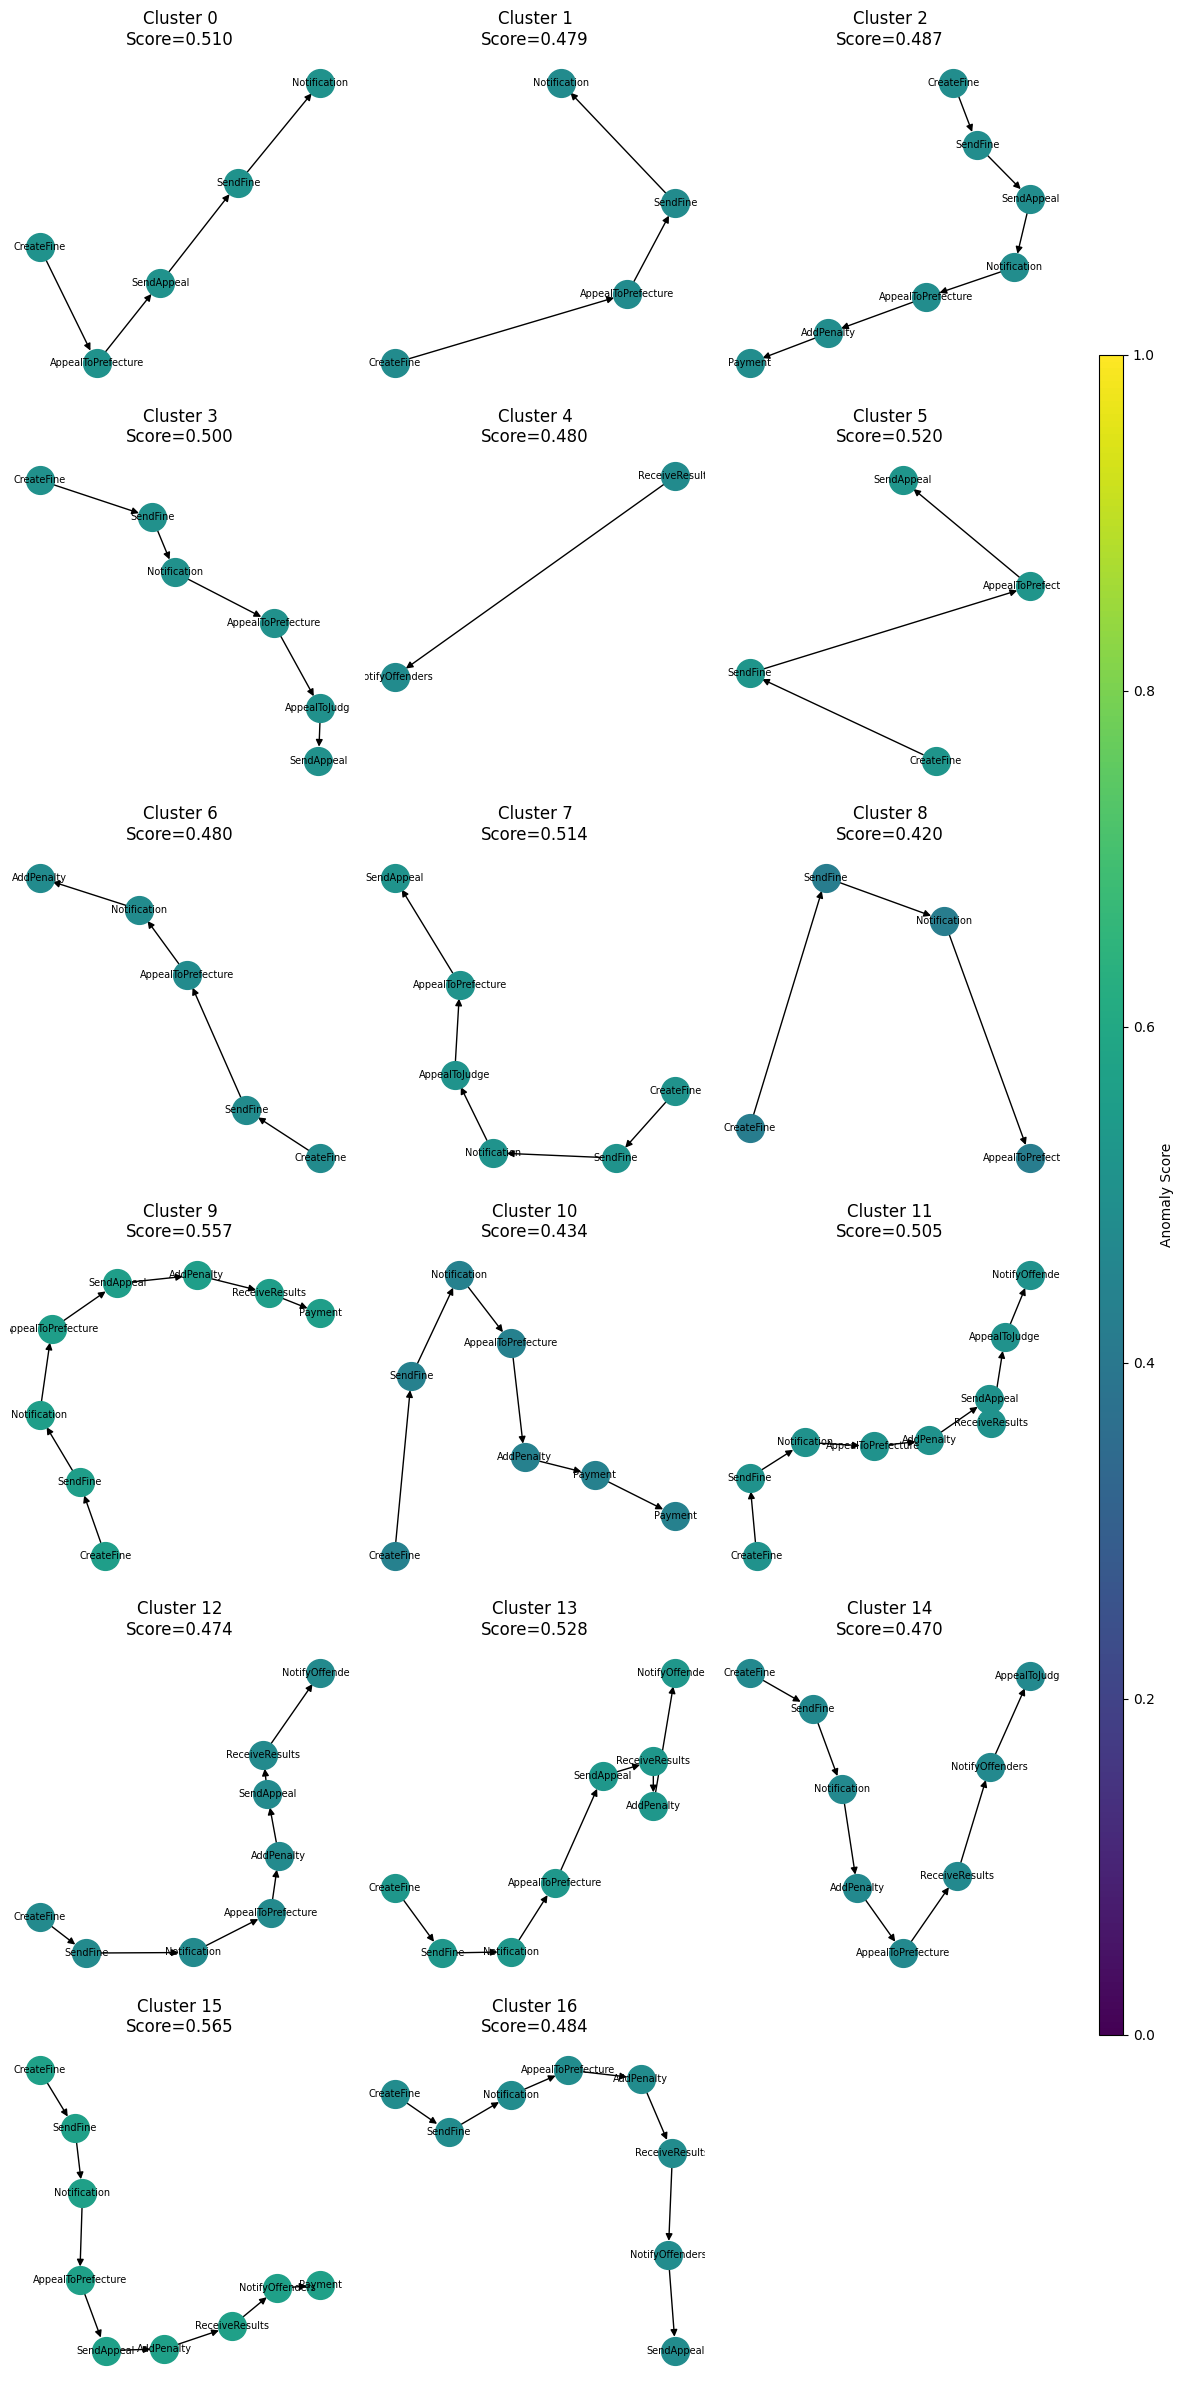

In [37]:

def plot_prototypes_grid(prototypes, scores, cols=3):

    n = len(prototypes)
    rows = int(np.ceil(n / cols))

    colormap = cm.get_cmap("viridis")

    fig = plt.figure(figsize=(4 * cols, 4 * rows))

    # ===============================
    # Plot grafi
    # ===============================

    for idx, (cluster_id, G_proto) in enumerate(prototypes.items()):

        score = scores.get(cluster_id, 0.0)

        color = colormap(score)

        ax = plt.subplot(rows, cols, idx + 1)

        pos = nx.spring_layout(G_proto)

        labels = nx.get_node_attributes(G_proto, 'label')

        nx.draw(
            G_proto,
            pos,
            node_color=[color],
            with_labels=True,
            labels=labels,
            node_size=400,
            font_size=7,
            ax=ax
        )

        plt.title(f"Cluster {cluster_id}\nScore={score:.3f}")

    # ===============================
    # Colorbar laterale globale
    # ===============================
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

    sm = plt.cm.ScalarMappable(
        cmap=colormap,
        norm=plt.Normalize(vmin=0, vmax=1)
    )

    sm.set_array([])

    fig.colorbar(sm, cax=cbar_ax, label="Anomaly Score")

    plt.subplots_adjust(right=0.9)
    plt.tight_layout(rect=[0, 0, 0.9, 1])

    plt.show()


# ===============================
# Plot grid prototypes
# ===============================

plot_prototypes_grid(prototypes, scores)